In [10]:
# Fig 2 BCD S1 center physio 5/20/40 Hz

In [11]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import glob
import os
import pickle
import sys
import scipy.io
import re
from scipy.spatial import distance
from scipy.stats import zscore
from scipy.stats import zmap
from collections import defaultdict

%matplotlib inline

matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.sans-serif'] = 'Arial'

In [ ]:
dir = os.getcwd()
base_dir = os.path.dirname(dir)
data_dir = os.path.join(base_dir, 'data')

In [13]:
# global parameters for binning and plotting
laser_time = 5.5
sampleRate = 30000
num_trials = 50
bin_factor = 0.02 # the actual bin size in seconds.

fs = 30000
ntrials = 50

bin_size = int(sampleRate * bin_factor) #bin size in samples.
num_bins = int(laser_time / bin_factor) - 1 # Number of bins for the histogram

# Plotting
# Define the time range you want to plot (between 2 and 4 seconds)
start_time = 0.5
end_time = 2
# Find the corresponding indices in the time_axis array
time_axis = np.linspace(0, laser_time, int(laser_time / bin_factor), endpoint = False)


In [14]:
# load z scored FR data and unit order
zfr_dict_file = os.path.join(data_dir,'zfr_dict_pawcenter.pickle')
with open(zfr_dict_file, 'rb') as handle:
    zfr_dict = pickle.load(handle)

nunits_cum_sum_layers_file = os.path.join(data_dir,'nunits_cum_sum_layers_pawcenter.npy')
nunits_select_cum_sum_layers = np.load(nunits_cum_sum_layers_file)

units_sort_by_depth_file = os.path.join(data_dir,'units_sort_by_depth_pawcenter.npy')
units_sort_by_depth = np.load(units_sort_by_depth_file)

nunits = len(units_sort_by_depth)

In [15]:
zfr_dict
selected_zfr_physio_all = zfr_dict['physio']
selected_zfr_5Hz_all = zfr_dict['5Hz']
selected_zfr_20Hz_all = zfr_dict['20Hz']
selected_zfr_40Hz_all = zfr_dict['40Hz']

zfr_mean_physio = np.mean(zfr_dict['physio'], axis=0)
zfr_mean_5Hz = np.mean(zfr_dict['5Hz'], axis=0)
zfr_mean_20Hz = np.mean(zfr_dict['20Hz'], axis=0)
zfr_mean_40Hz = np.mean(zfr_dict['20Hz'], axis=0)

zfr_std_physio = np.std(zfr_dict['physio'], axis=0)
zfr_std_5Hz = np.std(zfr_dict['5Hz'], axis=0)
zfr_std_20Hz = np.std(zfr_dict['20Hz'], axis=0)
zfr_std_40Hz = np.std(zfr_dict['40Hz'], axis=0)

In [16]:
### load physiology laser pattern
### plot physiology, 5/20/40 Hz
physio_file = os.path.join(data_dir, 'sync_samp', 'saltmr_trace4.npy')
# physio_file = r"N:\Liu_Wanyi\code_TrkC\SA-LTMR example traces\saltmr_trace4.npy"
trace_physio = np.load(physio_file)
trace_5Hz = np.arange(0, 0.5, 1/5)
trace_20Hz = np.arange(0, 0.5, 1/20)
trace_40Hz = np.arange(0, 0.5, 1/40)

In [17]:
# load example unit for raster
iunit_example_file = os.path.join(data_dir,'unit_example_TrkC_center.pickle')
with open(iunit_example_file, 'rb') as handle:
     iunit_dict_example = pickle.load(handle)

C:\Users\wanyiliu\AppData\Local\Temp\ipykernel_10960\2866792790.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.95, 1])


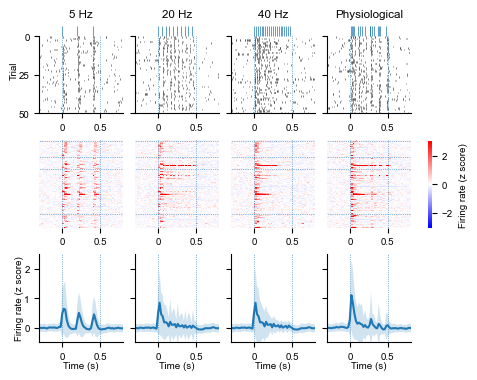

In [18]:
# add laser patterns above heatmap - add raster plots of example unit - new unit

f, ax = plt.subplots(3,4,figsize=[4.5,3.6],gridspec_kw={'height_ratios':[5,5,5]})

im0 = sns.heatmap(ax=ax[1,3], data = selected_zfr_physio_all[units_sort_by_depth], vmin=-3, vmax=3,cbar=False, cmap = 'bwr')
im1 = sns.heatmap(ax=ax[1,0], data = selected_zfr_5Hz_all[units_sort_by_depth], vmin=-3, vmax=3,cbar=False, cmap = 'bwr')
im2 = sns.heatmap(ax=ax[1,1], data = selected_zfr_20Hz_all[units_sort_by_depth], vmin=-3, vmax=3,cbar=False, cmap = 'bwr')
im3 = sns.heatmap(ax=ax[1,2], data = selected_zfr_40Hz_all[units_sort_by_depth], vmin=-3, vmax=3,cbar=False, cmap = 'bwr')

for i in [0,1,2,3]:

    ax[1,i].vlines(50, 0, nunits, linestyles= ':', linewidth = 0.5)
    ax[1,i].vlines(75, 0, nunits, linestyles= ':', linewidth = 0.5)
    ax[1,i].hlines(nunits_select_cum_sum_layers[:-1], 0, 100, linestyles= ':', linewidth = 0.5)

    ax[1,i].set_xlim(35,90)
    ax[1,i].set_xticks([])
    ax[1,i].set_yticks([])
    ax[1,i].set_xlabel('')
    ax[1,i].set_ylabel('')

    ax[1,i].set_xticks(ticks=[50,75], labels=[0,0.5], rotation = 0)

ax[2,3].plot(time_axis[0:200], zfr_mean_physio)
ax[2,0].plot(time_axis[0:200], zfr_mean_5Hz)
ax[2,1].plot(time_axis[0:200], zfr_mean_20Hz)
ax[2,2].plot(time_axis[0:200], zfr_mean_40Hz)

ax[2,3].fill_between(time_axis[0:200],zfr_mean_physio-zfr_std_physio,zfr_mean_physio+zfr_std_physio, alpha=0.2)
ax[2,0].fill_between(time_axis[0:200],zfr_mean_5Hz-zfr_std_5Hz,zfr_mean_5Hz+zfr_std_5Hz, alpha=0.2)
ax[2,1].fill_between(time_axis[0:200],zfr_mean_20Hz-zfr_std_20Hz,zfr_mean_20Hz+zfr_std_20Hz, alpha=0.2)
ax[2,2].fill_between(time_axis[0:200],zfr_mean_40Hz-zfr_std_40Hz,zfr_mean_40Hz+zfr_std_40Hz, alpha=0.2)

norm = plt.Normalize(vmin=-3, vmax=3)
sm = plt.cm.ScalarMappable(cmap='bwr', norm=norm)
sm.set_array([]) # an empty array is sufficient

cbar_ax = f.add_axes([0.95, 0.4, 0.01, 0.24]) # [left, bottom, width, height]
cbar = f.colorbar(sm, cbar_ax, label='Firing rate (z score)')
cbar.outline.set_visible(False)
plt.tight_layout(rect=[0, 0, 0.95, 1])

for i in [0,1,2,3]:

    ax[2,i].vlines(1, -0.5, 3, linestyles= ':', linewidth = 0.5)
    ax[2,i].vlines(1.5, -0.5, 3, linestyles= ':', linewidth = 0.5)
    ax[2,i].set_xlim(0.7,1.8)
    ax[2,i].set_ylim(-0.5,2.5)
    ax[2,i].set_xticks([])
    ax[2,i].set_xlabel('')

    ax[2,i].spines['top'].set_visible(False)
    ax[2,i].spines['right'].set_visible(False)

    ax[2,i].set_xlabel('Time (s)', labelpad=0)

    ax[2,i].set_xticks(ticks=[1,1.5], labels=[0,0.5], rotation = 0)

ax[2,0].set_ylabel('Firing rate (z score)', labelpad=0)

ax[2,1].set_yticklabels([])
ax[2,2].set_yticklabels([])
ax[2,3].set_yticklabels([])

spk_time_physio = iunit_dict_example['spk_time_physio']
spk_time_5Hz = iunit_dict_example['spk_time_5Hz']
spk_time_20Hz = iunit_dict_example['spk_time_20Hz']
spk_time_40Hz = iunit_dict_example['spk_time_40Hz']

yplot = 0

for itrial in range(ntrials):

    ax[0,0].vlines(spk_time_5Hz[itrial]-1, ymin=yplot, ymax=yplot+1,color="#555555",linewidth=0.5)
    ax[0,1].vlines(spk_time_20Hz[itrial]-1, ymin=yplot, ymax=yplot+1,color="#555555",linewidth=0.5)
    ax[0,2].vlines(spk_time_40Hz[itrial]-1, ymin=yplot, ymax=yplot+1,color="#555555",linewidth=0.5)
    ax[0,3].vlines(spk_time_physio[itrial]-1, ymin=yplot, ymax=yplot+1,color="#555555",linewidth=0.5)
    yplot +=1


ax[0,3].vlines(trace_physio,  ymin=-7, ymax=0, color='#1f77b4', linewidth=0.5)
ax[0,0].vlines(trace_5Hz,     ymin=-7, ymax=0, color='#1f77b4', linewidth=0.5)
ax[0,1].vlines(trace_20Hz,    ymin=-7, ymax=0, color='#1f77b4', linewidth=0.5)
ax[0,2].vlines(trace_40Hz,    ymin=-7, ymax=0, color='#1f77b4', linewidth=0.5)

for i in [0,1,2,3]:
    ax[0,i].vlines(0, 0, ntrials, linestyles= ':', linewidth = 0.5)
    ax[0,i].vlines(0.5, 0, ntrials, linestyles= ':', linewidth = 0.5)
    ax[0,i].set_xlim(-0.3,0.8)
    ax[0,i].set_ylim(-7,50)
    ax[0,i].spines['top'].set_visible(False)
    ax[0,i].spines['right'].set_visible(False)
    ax[0,i].spines['bottom'].set_zorder(0)
    ax[0,i].spines['left'].set_bounds((0, 50))
    ax[0,i].set_xticks([0,0.5])
    ax[0,i].set_xticklabels([0,0.5])
    ax[0,i].set_yticks([0,25,50])
    ax[0,i].set_yticklabels([])
    ax[0,i].invert_yaxis()

ax[0,0].set_ylabel('Trial',labelpad=0)
ax[0,0].set_yticklabels([0,25,50])

ax[0,3].set_title('Physiological')
ax[0,0].set_title('5 Hz')
ax[0,1].set_title('20 Hz')
ax[0,2].set_title('40 Hz')

plt.subplots_adjust(hspace=0.3, wspace=0.15) 

# plt.savefig(r"N:\Liu_Wanyi\TrkC_figures2\heatmap_laserTraces_Andrew_zeta_add_2.pdf",dpi=600,bbox_inches='tight',transparent=True)

plt.show()